# Simple Convolutional Neural Network to Perform Classification

### EN3150 Pattern Recognition
##### Team Intellivawe

### Imports

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_dir = "data"
IMG_SIZE = 64
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
total_size = len(dataset)
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", dataset.classes)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print(f"Ratios: {round(len(train_dataset)/total_size * 100)}% / "
      f"{round(len(val_dataset)/total_size * 100)}% / {round(len(test_dataset)/total_size * 100)}%")



Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 3919
Validation: 840
Test: 841
Ratios: 70% / 15% / 15%


### CNN A

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BrainTumorCNN_A(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 6 * 6, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model_A = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)

print(model_A)

BrainTumorCNN_A(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4608, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [17]:
from torchinfo import summary

summary(
    model_A,
    input_size=(1, 3, 64, 64)
)

Layer (type:depth-idx)                   Output Shape              Param #
BrainTumorCNN_A                          [1, 4]                    --
├─Conv2d: 1-1                            [1, 32, 62, 62]           896
├─MaxPool2d: 1-2                         [1, 32, 31, 31]           --
├─Conv2d: 1-3                            [1, 64, 29, 29]           18,496
├─MaxPool2d: 1-4                         [1, 64, 14, 14]           --
├─Conv2d: 1-5                            [1, 128, 12, 12]          73,856
├─MaxPool2d: 1-6                         [1, 128, 6, 6]            --
├─Flatten: 1-7                           [1, 4608]                 --
├─Linear: 1-8                            [1, 128]                  589,952
├─Dropout: 1-9                           [1, 128]                  --
├─Linear: 1-10                           [1, 4]                    516
Total params: 683,716
Trainable params: 683,716
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 30.23
Input size (MB): 0.05
Forwa

### CNN B

In [21]:
import torch
import torch.nn as nn

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, padding=1,
            groups=in_channels, bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, bias=False
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.relu(x)
        return x


class ModelB(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            DepthwiseSeparableConv(3, 32),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(32, 64),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(64, 128),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(128, 128),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def count_trainable_params(model):
    return sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )


model_B = ModelB(num_classes=len(dataset.classes)).to(device)

print(model_B)

ModelB(
  (features): Sequential(
    (0): DepthwiseSeparableConv(
      (depthwise): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=3, bias=False)
      (pointwise): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (relu): ReLU()
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (relu): ReLU()
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): DepthwiseSeparableConv(
      (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
      (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (relu): ReLU()
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0,

In [23]:
from torchinfo import summary
summary(model_B, input_size=(1, 3, 64, 64))


Layer (type:depth-idx)                   Output Shape              Param #
ModelB                                   [1, 4]                    --
├─Sequential: 1-1                        [1, 128, 1, 1]            --
│    └─DepthwiseSeparableConv: 2-1       [1, 32, 64, 64]           --
│    │    └─Conv2d: 3-1                  [1, 3, 64, 64]            27
│    │    └─Conv2d: 3-2                  [1, 32, 64, 64]           96
│    │    └─ReLU: 3-3                    [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-2                    [1, 32, 32, 32]           --
│    └─DepthwiseSeparableConv: 2-3       [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-4                  [1, 32, 32, 32]           288
│    │    └─Conv2d: 3-5                  [1, 64, 32, 32]           2,048
│    │    └─ReLU: 3-6                    [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-4                    [1, 64, 16, 16]           --
│    └─DepthwiseSeparableConv: 2-5       [1, 128, 16, 16]          --
│    │    └

In [24]:
print(f"\nModel B trainable parameters: {count_trainable_params(model_B):,}")


Model B trainable parameters: 37,279


### Training the Models

In [26]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, val_loader, optimizer, epochs=20):
    train_losses = []
    val_losses = []
    epoch_times = []

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)

        epoch_time = time.time() - start_time

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        epoch_times.append(epoch_time)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Time: {epoch_time:.2f}s"
        )

    return train_losses, val_losses, epoch_times

Train Model A

In [27]:
model_A = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)

optimizer_A = optim.Adam(
    model_A.parameters(),
    lr=0.001
)

train_loss_A, val_loss_A, time_A = train_model(
    model_A,
    train_loader,
    val_loader,
    optimizer_A,
    epochs=20
)

Epoch [1/20] Train Loss: 0.9216 Val Loss: 0.6594 Time: 45.10s
Epoch [2/20] Train Loss: 0.6172 Val Loss: 0.5159 Time: 16.24s
Epoch [3/20] Train Loss: 0.5196 Val Loss: 0.4434 Time: 15.09s
Epoch [4/20] Train Loss: 0.4166 Val Loss: 0.3775 Time: 14.81s
Epoch [5/20] Train Loss: 0.3639 Val Loss: 0.3480 Time: 14.86s
Epoch [6/20] Train Loss: 0.3049 Val Loss: 0.3231 Time: 15.50s
Epoch [7/20] Train Loss: 0.2689 Val Loss: 0.2848 Time: 15.71s
Epoch [8/20] Train Loss: 0.2162 Val Loss: 0.2780 Time: 15.35s
Epoch [9/20] Train Loss: 0.1820 Val Loss: 0.2713 Time: 15.72s
Epoch [10/20] Train Loss: 0.1637 Val Loss: 0.2596 Time: 15.76s
Epoch [11/20] Train Loss: 0.1295 Val Loss: 0.3559 Time: 15.65s
Epoch [12/20] Train Loss: 0.1105 Val Loss: 0.2925 Time: 16.61s
Epoch [13/20] Train Loss: 0.1017 Val Loss: 0.2508 Time: 15.76s
Epoch [14/20] Train Loss: 0.0924 Val Loss: 0.2435 Time: 15.44s
Epoch [15/20] Train Loss: 0.0776 Val Loss: 0.2267 Time: 16.15s
Epoch [16/20] Train Loss: 0.0733 Val Loss: 0.2856 Time: 15.53s
E

Train Model B

In [28]:
modelB = ModelB(num_classes=len(dataset.classes)).to(device)

optimizer_B = optim.Adam(
    modelB.parameters(),
    lr=0.001
)

train_loss_B, val_loss_B, time_B = train_model(
    modelB,
    train_loader,
    val_loader,
    optimizer_B,
    epochs=20
)

Epoch [1/20] Train Loss: 1.3773 Val Loss: 1.3425 Time: 20.86s
Epoch [2/20] Train Loss: 1.2257 Val Loss: 1.0771 Time: 21.67s
Epoch [3/20] Train Loss: 1.0582 Val Loss: 0.9517 Time: 21.69s
Epoch [4/20] Train Loss: 0.8939 Val Loss: 0.9543 Time: 19.95s
Epoch [5/20] Train Loss: 0.8286 Val Loss: 0.7471 Time: 17.20s
Epoch [6/20] Train Loss: 0.7949 Val Loss: 0.7326 Time: 15.56s
Epoch [7/20] Train Loss: 0.7672 Val Loss: 0.7628 Time: 15.46s
Epoch [8/20] Train Loss: 0.7482 Val Loss: 0.6762 Time: 15.69s
Epoch [9/20] Train Loss: 0.7145 Val Loss: 0.6701 Time: 15.39s
Epoch [10/20] Train Loss: 0.6934 Val Loss: 0.6417 Time: 15.47s
Epoch [11/20] Train Loss: 0.6918 Val Loss: 0.6409 Time: 15.49s
Epoch [12/20] Train Loss: 0.6725 Val Loss: 0.6271 Time: 16.04s
Epoch [13/20] Train Loss: 0.6495 Val Loss: 0.6211 Time: 15.95s
Epoch [14/20] Train Loss: 0.6454 Val Loss: 0.6046 Time: 16.37s
Epoch [15/20] Train Loss: 0.6357 Val Loss: 0.5839 Time: 17.07s
Epoch [16/20] Train Loss: 0.6084 Val Loss: 0.5731 Time: 21.09s
E

Plot loss curves

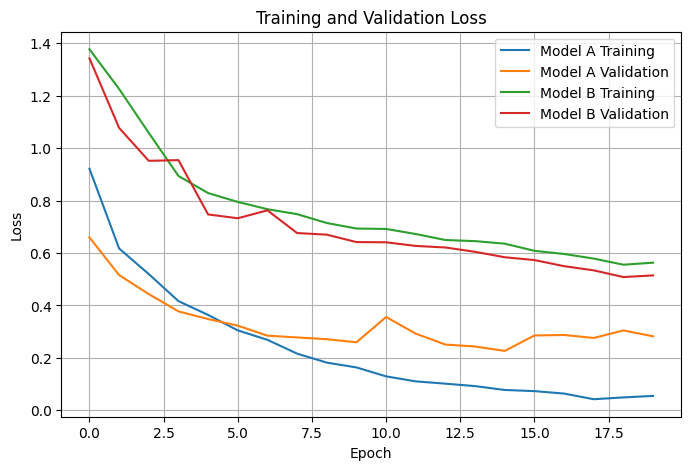

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss_A, label="Model A Training")
plt.plot(val_loss_A, label="Model A Validation")
plt.plot(train_loss_B, label="Model B Training")
plt.plot(val_loss_B, label="Model B Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

Test evaluation

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_model(model, test_loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, cm

In [34]:
acc_A, precision_A, recall_A, cm_A = evaluate_model(
    model_A, test_loader
)

acc_B, precision_B, recall_B, cm_B = evaluate_model(
    modelB, test_loader
)

print("Model A")
print("Accuracy :", acc_A)
print("Precision:", precision_A)
print("Recall   :", recall_A)


print("\nModel B")
print("Accuracy :", acc_B)
print("Precision:", precision_B)
print("Recall   :", recall_B)


Model A
Accuracy : 0.9084423305588585
Precision: 0.9082162539615641
Recall   : 0.9084423305588585

Model B
Accuracy : 0.7586206896551724
Precision: 0.7460396694003106
Recall   : 0.7586206896551724


Confusion matrices

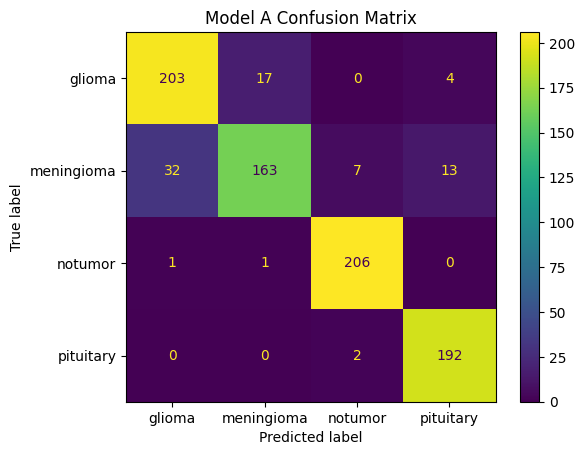

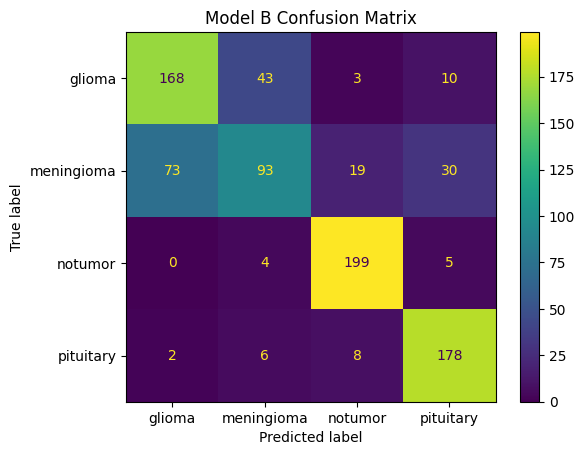

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    cm_A,
    display_labels=dataset.classes
).plot()

plt.title("Model A Confusion Matrix")
plt.show()

ConfusionMatrixDisplay(
    cm_B,
    display_labels=dataset.classes
).plot()

plt.title("Model B Confusion Matrix")
plt.show()

Model comparison table

In [33]:
params_A = sum(p.numel() for p in model_A.parameters() if p.requires_grad)
params_B = sum(p.numel() for p in modelB.parameters() if p.requires_grad)

print("Model A parameters:", params_A)
print("Model B parameters:", params_B)

print("Model A average epoch time:", sum(time_A) / len(time_A), "seconds")
print("Model B average epoch time:", sum(time_B) / len(time_B), "seconds")

Model A parameters: 683716
Model B parameters: 37279
Model A average epoch time: 17.141073870658875 seconds
Model B average epoch time: 17.59701919555664 seconds


Model A achieved a test accuracy of 90.84%, while Model B achieved 75.86%. Although Model B significantly reduces the number of trainable parameters and computational complexity through depthwise separable convolutions, this reduction in model complexity resulted in lower classification performance on the test dataset. This demonstrates the trade-off between computational efficiency and classification accuracy.

### Compare Adam, SGD and SGD + Momentum

Model A + Adam

Model A + SGD

Model A + SGD with Momentum

In [41]:
# Adam
model_adam = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

# SGD
model_sgd = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

# SGD + Momentum
model_momentum = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_momentum = optim.SGD(
    model_momentum.parameters(),
    lr=0.01,
    momentum=0.9
)

In [42]:
train_adam, val_adam, time_adam = train_model(
    model_adam, train_loader, val_loader,
    optimizer_adam, epochs=20
)

train_sgd, val_sgd, time_sgd = train_model(
    model_sgd, train_loader, val_loader,
    optimizer_sgd, epochs=20
)

train_momentum, val_momentum, time_momentum = train_model(
    model_momentum, train_loader, val_loader,
    optimizer_momentum, epochs=20
)

Epoch [1/20] Train Loss: 0.9143 Val Loss: 0.6474 Time: 19.02s
Epoch [2/20] Train Loss: 0.5881 Val Loss: 0.4885 Time: 20.27s
Epoch [3/20] Train Loss: 0.4802 Val Loss: 0.4409 Time: 20.07s
Epoch [4/20] Train Loss: 0.4113 Val Loss: 0.3879 Time: 19.38s
Epoch [5/20] Train Loss: 0.3387 Val Loss: 0.3373 Time: 17.72s
Epoch [6/20] Train Loss: 0.2920 Val Loss: 0.3123 Time: 18.92s
Epoch [7/20] Train Loss: 0.2644 Val Loss: 0.3303 Time: 18.70s
Epoch [8/20] Train Loss: 0.2102 Val Loss: 0.3350 Time: 16.42s
Epoch [9/20] Train Loss: 0.2030 Val Loss: 0.2611 Time: 15.55s
Epoch [10/20] Train Loss: 0.1680 Val Loss: 0.3015 Time: 16.87s
Epoch [11/20] Train Loss: 0.1304 Val Loss: 0.2453 Time: 15.78s
Epoch [12/20] Train Loss: 0.1198 Val Loss: 0.2609 Time: 15.43s
Epoch [13/20] Train Loss: 0.1098 Val Loss: 0.2371 Time: 15.54s
Epoch [14/20] Train Loss: 0.0968 Val Loss: 0.3728 Time: 13.98s
Epoch [15/20] Train Loss: 0.0863 Val Loss: 0.2688 Time: 13.97s
Epoch [16/20] Train Loss: 0.0684 Val Loss: 0.3137 Time: 14.61s
E

Compare the results

In [43]:
for name, model in [
    ("Adam", model_adam),
    ("SGD", model_sgd),
    ("SGD + Momentum", model_momentum)
]:
    acc, precision, recall, cm = evaluate_model(model, test_loader)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")


Adam
Accuracy : 0.9049
Precision: 0.9039
Recall   : 0.9049

SGD
Accuracy : 0.7776
Precision: 0.7934
Recall   : 0.7776

SGD + Momentum
Accuracy : 0.9239
Precision: 0.9247
Recall   : 0.9239


Three optimizers, Adam, SGD, and SGD with Momentum, were compared using the same CNN architecture and 20 training epochs. Adam achieved 90.49% accuracy, while standard SGD achieved 77.76%. SGD with Momentum achieved the highest accuracy of 92.39%. This shows that momentum helped improve convergence and classification performance compared with standard SGD.

The improvement obtained with momentum can be explained by the use of previous update information when adjusting the model parameters. This helps reduce oscillations during optimization and can allow the model to move more smoothly toward a lower-loss solution. Therefore, momentum improved the convergence and final classification performance compared with standard SGD in this experiment.

Based on these results, SGD with Momentum was used as the optimizer for the subsequent model training experiments.